# Bias Comparison

Bias is a slippery thing. When people attempt to determine whether a sentence, an article, or a piece of information contains bias, their perception is itself affected by their preexisting biases. 

In this project, we have two datasets, "MBIC" and "SG1", which contain 1700 sentences that have been checked for bias. MBIC's bias labels were crowdsourced, while SG1's labels were determined by a panel of eight experts. We'll be training two models, identical except in that one uses the MBIC data and the other uses the SG1 data, and then test both against a test set of Wikipedia articles. We'll then examine the differences in results between the two models, and ask: does MBIC's crowdsourced labelers perceive bias differently from SG1's expert labelers?

To start, we'll need to import some packages:



In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from textblob import TextBlob
import spacy

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV

import torch
from transformers import AutoTokenizer, AutoModel, pipeline

import openpyxl
import xlrd

# Just in case
import requests
from bs4 import BeautifulSoup

pd.set_option('display.max_colwidth', None)

In [2]:
spacy.load('en_core_web_sm')

# Importing datasets

In [3]:
dataset_path = os.path.join(os.curdir, 'datasets')

df_sg1 = pd.read_csv(os.path.join(dataset_path, 'final_labels_SG1.csv'), sep=';')
df_mbic = pd.read_csv(os.path.join(dataset_path, 'final_labels_MBIC.csv'), sep=';')
df_lex = pd.read_excel(os.path.join(dataset_path, 'bias_word_lexicon.xlsx'))

`df_sg1` and `df_mbic` contain our two training sets. `df_lex` contains a list of words that are often seen as biased.

Let's take a cursory look at our data:

In [4]:
df_sg1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           1700 non-null   object
 1   news_link      1672 non-null   object
 2   outlet         1700 non-null   object
 3   topic          1700 non-null   object
 4   type           1700 non-null   object
 5   label_bias     1700 non-null   object
 6   label_opinion  1700 non-null   object
 7   biased_words   1700 non-null   object
dtypes: object(8)
memory usage: 106.4+ KB


In [5]:
df_mbic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           1700 non-null   object
 1   news_link      1681 non-null   object
 2   outlet         1700 non-null   object
 3   topic          1700 non-null   object
 4   type           1700 non-null   object
 5   group_id       1700 non-null   int64 
 6   num_sent       1700 non-null   int64 
 7   label_bias     1700 non-null   object
 8   label_opinion  1700 non-null   object
 9   article        1595 non-null   object
 10  biased_words   1700 non-null   object
dtypes: int64(2), object(9)
memory usage: 146.2+ KB


In [6]:
#detecting duplicate entries
print(df_mbic['text'].duplicated().value_counts())
df_sg1['text'].duplicated().value_counts()

text
False    1700
Name: count, dtype: int64


text
False    1700
Name: count, dtype: int64

Here we see that our datasets contain mostly the same columns, with `df_mbic` adding `group_id`, `num_sent`, and `article`. In order to ensure our comparison is fair, we'll need to remove those. However, while the source for the data sets claims they contain the same 1700 sentences, we should check that that's actually the case. We can do this by sorting each column and comparing row-by-row:

In [7]:
mbic_text_sort = df_mbic['text'].sort_values(ascending=True)
sg1_text_sort = df_sg1['text'].sort_values(ascending=True)
comparison = pd.Series(mbic_text_sort.values == sg1_text_sort.values)
comparison.value_counts()

True     1456
False     244
Name: count, dtype: int64

It seems that there are some differences in a few hundred of the texts. We can examine them individually:

In [8]:
mbic_check = df_mbic[df_mbic['text'].sort_values(ascending=True).values != df_sg1['text'].sort_values(ascending=True).values]
sg1_check = df_sg1[df_mbic['text'].sort_values(ascending=True).values != df_sg1['text'].sort_values(ascending=True).values]
mbic_check.info()


<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 1454 to 1697
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           244 non-null    object
 1   news_link      244 non-null    object
 2   outlet         244 non-null    object
 3   topic          244 non-null    object
 4   type           244 non-null    object
 5   group_id       244 non-null    int64 
 6   num_sent       244 non-null    int64 
 7   label_bias     244 non-null    object
 8   label_opinion  244 non-null    object
 9   article        204 non-null    object
 10  biased_words   244 non-null    object
dtypes: int64(2), object(9)
memory usage: 22.9+ KB


In [9]:
spotcheck = sg1_check['text'].sort_values(ascending=True).head(1).values[0]
spotcheck

'"Orange Is the New Black" star Yael Stone is renouncing her U.S. green card to return to her native Australia in order to fight climate change.'

In [10]:
mbic_check['text'].str.contains(spotcheck).value_counts()

text
False    244
Name: count, dtype: int64

In [11]:
df_mbic['text'].str.contains(spotcheck).value_counts()

text
False    1699
True        1
Name: count, dtype: int64

As we can see, while the subset of MBIC entries that mismatched in our check didn't contain a mention of Yael Stone, the exact sentence was found elsewhere in `df_mbic`. This suggests a possible issue with the comparison. The dataframes don't sort the texts identically, and it appears sorting them ourselves didn't solve every discrepancy. We'll need a more robust check. `isin` lets us check if an array or Series is present in some other array or series. We can demonstrate it like so:

In [12]:
mbic_check['text'].isin(df_mbic['text']).value_counts()

text
True    244
Name: count, dtype: int64

Of course all of the `mbic_check` texts are in `df_mbic`, that's where we got them. Having shown how this works, we can see if every `df_mbic` text is in `df_sg1` and vice-versa:

In [13]:
df_mbic['text'].isin(df_sg1['text']).value_counts()

text
True     1698
False       2
Name: count, dtype: int64

Exactly one of them is missing. Does the same comparison hold true in the opposite direction?

In [14]:
df_sg1['text'].isin(df_mbic['text']).value_counts()

text
True     1698
False       2
Name: count, dtype: int64

There are exactly two mismatches. Let's see if we can find them in their respective dataframes:

In [15]:
#df_mbic questionable entries
df_mbic['text'].isin(df_sg1['text']).sort_values()

1544    False
923     False
0        True
1138     True
1137     True
        ...  
561      True
560      True
559      True
557      True
1699     True
Name: text, Length: 1700, dtype: bool

In [16]:
#df_sg1 questionable entries
df_sg1['text'].isin(df_mbic['text']).sort_values()

423     False
453     False
1140     True
1139     True
1138     True
        ...  
563      True
562      True
561      True
559      True
1699     True
Name: text, Length: 1700, dtype: bool

In [17]:
#mbic indices 1544 and 923 need checked
df_mbic.iloc[923]['text']

'his is another example of Trump’s false dichotomy between saving the economy and fighting the virus. After all, the economy isn’t going to recover if millions are sick and people are afraid to leave their houses — and early evidence from the states that have tried to “reopen” their economies makes that clear.'

In [18]:
df_mbic.iloc[1544]['text']

'Two Democrats -- state Sens. Creigh Deeds and Chap Petersen -- joined with\xa0Republicansto defeat the measure.'

In [19]:
#sg1 indices 423 and 425 need checked
df_sg1.iloc[423]['text']

'Two Democrats -- state Sens. Creigh Deeds and Chap Petersen -- joined with\xa0Republicans to defeat the measure.'

In [20]:
df_sg1.iloc[453]['text']

'This is another example of Trump’s false dichotomy between saving the economy and fighting the virus. After all, the economy isn’t going to recover if millions are sick and people are afraid to leave their houses — and early evidence from the states that have tried to “reopen” their economies makes that clear.'

Both remaining mismatches are the result of typographical errors--`'Republicans to'` is missing the space in `df_mbic.iloc[1544]` and `'This'` is missing the first letter in MBIC as well. We can fix that like so:

In [21]:
df_mbic.loc[1544, 'text'] = df_sg1.loc[423, 'text']
df_mbic.loc[1544, 'text']

'Two Democrats -- state Sens. Creigh Deeds and Chap Petersen -- joined with\xa0Republicans to defeat the measure.'

In [22]:
df_mbic.loc[923, 'text'] = df_sg1.loc[453, 'text']
df_mbic.loc[923, 'text']

'This is another example of Trump’s false dichotomy between saving the economy and fighting the virus. After all, the economy isn’t going to recover if millions are sick and people are afraid to leave their houses — and early evidence from the states that have tried to “reopen” their economies makes that clear.'

In [23]:
#now the comparison should return only True
df_mbic['text'].isin(df_sg1['text']).value_counts()

text
True    1700
Name: count, dtype: int64

Seems like we've cleaned this part of the data up. We'll need to remove a few columns that are only present in one or the other, as well as look at `news_link` which has some null values.

In [24]:
df_sg1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           1700 non-null   object
 1   news_link      1672 non-null   object
 2   outlet         1700 non-null   object
 3   topic          1700 non-null   object
 4   type           1700 non-null   object
 5   label_bias     1700 non-null   object
 6   label_opinion  1700 non-null   object
 7   biased_words   1700 non-null   object
dtypes: object(8)
memory usage: 106.4+ KB


In [25]:
df_mbic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           1700 non-null   object
 1   news_link      1681 non-null   object
 2   outlet         1700 non-null   object
 3   topic          1700 non-null   object
 4   type           1700 non-null   object
 5   group_id       1700 non-null   int64 
 6   num_sent       1700 non-null   int64 
 7   label_bias     1700 non-null   object
 8   label_opinion  1700 non-null   object
 9   article        1595 non-null   object
 10  biased_words   1700 non-null   object
dtypes: int64(2), object(9)
memory usage: 146.2+ KB


`group_id`, `num_sent`, and `article` are all present in `df_mbic` but not `df_sg1`. Our attempt at comparison only makes sense if our training features are as similar as possible, so let's drop those:

In [26]:
df_mbic = df_mbic.drop(labels=['group_id', 'num_sent', 'article'], axis=1)
df_mbic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           1700 non-null   object
 1   news_link      1681 non-null   object
 2   outlet         1700 non-null   object
 3   topic          1700 non-null   object
 4   type           1700 non-null   object
 5   label_bias     1700 non-null   object
 6   label_opinion  1700 non-null   object
 7   biased_words   1700 non-null   object
dtypes: object(8)
memory usage: 106.4+ KB


There's a clear difference related to `news_link` where there's a different amount of missing data in each. We can determine the extent of the difference much like we did with `text`:

In [27]:
df_mbic['news_link'].isin(df_sg1['news_link']).value_counts()

news_link
True     1691
False       9
Name: count, dtype: int64

In [28]:
df_sg1['news_link'].isin(df_mbic['news_link']).value_counts()

news_link
True    1700
Name: count, dtype: int64

Good news: every link in `df_sg1` is present in `df_mbic`, and given we know the texts are the same, we can just transplant ones that are missing from MBIC to SG1. The collection of all links missing from MBIC is:

In [29]:
replacement_links = df_mbic[~df_mbic['news_link'].isin(df_sg1['news_link'])].sort_values(by='text')
replacement_links['text'].head()

1338                                                                               After a two month shutdown, professional sports slowly began to re-emerge from under the COVID-19 cloud during the weekend as several events returned to television — all without fans in attendance.
367                                                                    But director Nick Sweeney’s forthcoming documentary on McCorvey, “AKA Jane Roe,” contains a major bombshell: her conversion from abortion rights icon to born-again Christian abortion opponent was “all an act.”
1604     In Wuhan’s Qiaokou district, at the Zirun Mingyuan apartment community where about 10,000 people live, men, women and children stood under umbrellas while elderly residents perched on stools as they waited to get tested at four sites set up in the middle of the compound.
169     Letters from GOP members of Congress and national pro-life leaders to the White House and the Food and Drug Administration (FDA) last week asserted D

To check that they're really not there, we could use the indices, except that the dataframes aren't sorted. We can, however, use `isna()`:

In [30]:
missing_links = df_sg1[df_sg1['news_link'].isna()].sort_values(by='text')
missing_links['text'].head()

249                                                                                                                                                                                             Abortion propaganda was always meant to obscure the reality of abortion, not justify it.
502                                                                                After a two month shutdown, professional sports slowly began to re-emerge from under the COVID-19 cloud during the weekend as several events returned to television — all without fans in attendance.
1323                             An investigative journalist whose exposés on the deep-rooted corruption in African soccer led to the downfall of a member of the high-powered FIFA Council was shot dead Wednesday, months after a Ghana politician called for retribution against him.
1626                                                                   But director Nick Sweeney’s forthcoming documentary on McCorvey, “AKA Jane Roe,” conta

While this also includes links that are missing from both datasets, the `missing_links` texts are included (`head()` has been added to prevent an oversized table). Manually reentering them one-by-one would be unwieldy here, but pandas has tools we can use.

In [31]:
#cut missing_links to just the replaceable ones
missing_links = missing_links[missing_links['text'].isin(replacement_links['text'])]

#reset indices so that we can match replacement links to missing ones
missing_links = missing_links.reset_index()
replacement_links = replacement_links.reset_index()


In [32]:
missing_links == replacement_links

,index,text,news_link,outlet,topic,type,label_bias,label_opinion,biased_words
0,False,True,False,True,True,True,True,True,True
1,False,True,False,True,True,True,True,False,False
2,False,True,False,True,True,True,True,True,False
3,False,True,False,True,True,True,True,True,False
4,False,True,False,True,True,True,True,True,True
5,False,True,False,True,True,True,True,False,False
6,False,True,False,True,True,True,True,True,False
7,False,True,False,True,True,True,True,True,True
8,False,True,False,True,True,True,True,False,False


We can see that the two sets of nine rows are identical except for `news_link`, for obvious reasons, and also the specific biased words and opinion labels, which is interesting.

So, to find the rows in `df_sg1` that are missing links and replace the links, we can transfer the links from `replacement_links` to `missing_links` now that their indices are sorted the same, and then we can reindex `missing_links` and replace the appropriate rows in `df_sg1`:

In [33]:
missing_links['news_link'] = replacement_links['news_link']
missing_links['news_link']

0                      https://de.reuters.com/article/health-coronavirus-sport-usa/sport-california-new-york-open-door-for-sports-return-idUKL8N2D06FQ
1    https://www.alternet.org/2020/05/the-jig-is-up-the-woman-behind-roe-v-wade-became-a-hero-of-abortion-opponents-but-now-we-know-it-was-all-an-act/
2                                                                                                         https://ru.reuters.com/article/idUKL4N2CX0PC
3                                  https://www.breitbart.com/politics/2020/04/20/republicans-urge-trump-to-maintain-pro-life-policies-during-pandemic/
4                     https://www.breitbart.com/politics/2020/01/22/watch-live-pro-life-advocates-lay-3000-flowers-outside-scotus-to-remember-preborn/
5                                                                                                         https://ru.reuters.com/article/idUKL4N2CX0PC
6     https://www.reuters.com/article/us-health-coronavirus-usa-abortion/americans-divided-as-

In [34]:
missing_links.index = missing_links['index']
missing_links = missing_links.drop(labels='index', axis=1).sort_index()
missing_links['text']

index
74      Letters from GOP members of Congress and national pro-life leaders to the White House and the Food and Drug Administration (FDA) last week asserted Democrats are attempting to exploit the coronavirus pandemic for the purpose of advancing their party’s pro-abortion agenda.
502                                                                                After a two month shutdown, professional sports slowly began to re-emerge from under the COVID-19 cloud during the weekend as several events returned to television — all without fans in attendance.
673      In Wuhan’s Qiaokou district, at the Zirun Mingyuan apartment community where about 10,000 people live, men, women and children stood under umbrellas while elderly residents perched on stools as they waited to get tested at four sites set up in the middle of the compound.
687                                                    Residents in Wuhan braved pouring rain in queues of more than an hour to take part in a governme

In [35]:
df_sg1.iloc[missing_links.index] == missing_links
#shows that everything is identical except the links

,text,news_link,outlet,topic,type,label_bias,label_opinion,biased_words
74,True,False,True,True,True,True,True,True
502,True,False,True,True,True,True,True,True
673,True,False,True,True,True,True,True,True
687,True,False,True,True,True,True,True,True
889,True,False,True,True,True,True,True,True
984,True,False,True,True,True,True,True,True
1339,True,False,True,True,True,True,True,True
1439,True,False,True,True,True,True,True,True
1626,True,False,True,True,True,True,True,True


In [36]:
df_sg1.iloc[missing_links.index] = missing_links
df_sg1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           1700 non-null   object
 1   news_link      1681 non-null   object
 2   outlet         1700 non-null   object
 3   topic          1700 non-null   object
 4   type           1700 non-null   object
 5   label_bias     1700 non-null   object
 6   label_opinion  1700 non-null   object
 7   biased_words   1700 non-null   object
dtypes: object(8)
memory usage: 106.4+ KB


We've successfully transplanted the links. The 19 remaining missing article links can just be marked 'MISSING'.

In [37]:
df_mbic = df_mbic.fillna(value='MISSING', axis=0)
df_mbic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           1700 non-null   object
 1   news_link      1700 non-null   object
 2   outlet         1700 non-null   object
 3   topic          1700 non-null   object
 4   type           1700 non-null   object
 5   label_bias     1700 non-null   object
 6   label_opinion  1700 non-null   object
 7   biased_words   1700 non-null   object
dtypes: object(8)
memory usage: 106.4+ KB


In [38]:
df_sg1 = df_sg1.fillna(value='MISSING', axis=0)

With our data preprocessed, let's do some preliminary investigating.

# Exploratory Data Analysis

It's good to ask a few questions about our data to get to know it better. First:

## Did MBIC or SG1 find more bias?

In [39]:
df_mbic['label_bias'].value_counts()

label_bias
Biased          1018
Non-biased       533
No agreement     149
Name: count, dtype: int64

In [40]:
df_sg1['label_bias'].value_counts()

label_bias
Non-biased      800
Biased          746
No agreement    154
Name: count, dtype: int64

MBIC's crowdsourcing found more of the training text to be biased than SG1's team did. We can visualize the difference:

In [58]:
label_biases = pd.concat([df_mbic['label_bias'].value_counts(), df_sg1['label_bias'].value_counts()], axis=1)
label_biases.columns = ['MBIC', 'SG1']
label_biases.head()

,MBIC,SG1
label_bias,,
Biased,1018,746
Non-biased,533,800
No agreement,149,154


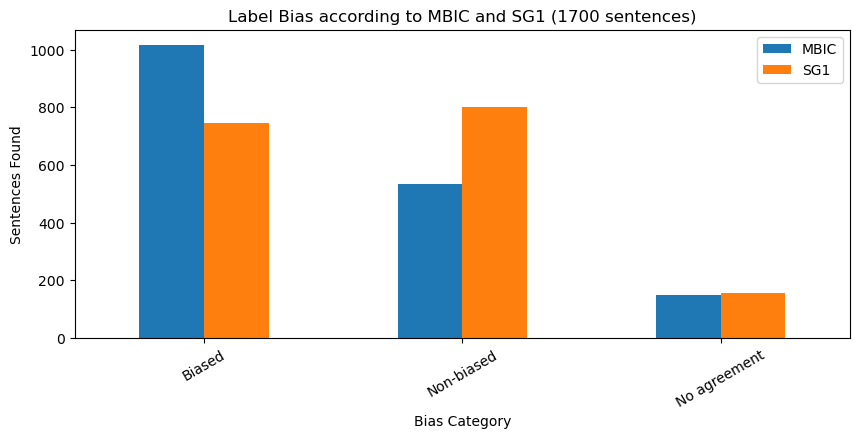

In [59]:

label_biases.plot(title='Label Bias according to MBIC and SG1 (1700 sentences)',
                            kind='bar', rot=30, xlabel='Bias Category', ylabel='Sentences Found',
                            figsize=[10, 4])

plt.show()

We can see that MBIC, the crowdsourced set, found more bias than SG1 did.

Another question:

## How many texts did MBIC and SG1 disagree on?

We can add a row to one dataframe reflecting the 'label_bias' from the other (we'll just have to be careful to remove it before we train the model!)

In [61]:
df_mbic['sg1_label_bias'] = df_sg1['label_bias']
df_mbic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   text            1700 non-null   object
 1   news_link       1700 non-null   object
 2   outlet          1700 non-null   object
 3   topic           1700 non-null   object
 4   type            1700 non-null   object
 5   label_bias      1700 non-null   object
 6   label_opinion   1700 non-null   object
 7   biased_words    1700 non-null   object
 8   sg1_label_bias  1700 non-null   object
dtypes: object(9)
memory usage: 119.7+ KB


In [67]:
label_mismatches = df_mbic.loc[df_mbic['label_bias'] != df_mbic['sg1_label_bias']]
label_mismatches.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1001 entries, 1 to 1699
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   text            1001 non-null   object
 1   news_link       1001 non-null   object
 2   outlet          1001 non-null   object
 3   topic           1001 non-null   object
 4   type            1001 non-null   object
 5   label_bias      1001 non-null   object
 6   label_opinion   1001 non-null   object
 7   biased_words    1001 non-null   object
 8   sg1_label_bias  1001 non-null   object
dtypes: object(9)
memory usage: 78.2+ KB


1001 of our 1700 texts had different bias labels between the two data sets. That's a huge disparity!

We can also find the ones that do match:

In [69]:
label_matches = df_mbic.loc[df_mbic['label_bias'] == df_mbic['sg1_label_bias']]
label_matches.info()

<class 'pandas.core.frame.DataFrame'>
Index: 699 entries, 0 to 1697
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   text            699 non-null    object
 1   news_link       699 non-null    object
 2   outlet          699 non-null    object
 3   topic           699 non-null    object
 4   type            699 non-null    object
 5   label_bias      699 non-null    object
 6   label_opinion   699 non-null    object
 7   biased_words    699 non-null    object
 8   sg1_label_bias  699 non-null    object
dtypes: object(9)
memory usage: 54.6+ KB


We can then compare these two data sets along different axes. For example:

## Were some news outlets more likely to cause disagreement between our data sets?

In [70]:
label_mismatches['outlet'].value_counts()

outlet
breitbart     223
alternet      202
msnbc         136
federalist    121
reuters        94
usa-today      85
fox-news       76
huffpost       64
Name: count, dtype: int64

In [71]:
label_matches['outlet'].value_counts()

outlet
breitbart     154
alternet      136
msnbc         106
federalist     82
usa-today      72
reuters        64
huffpost       50
fox-news       35
Name: count, dtype: int64

The order is roughly the same between the two data sets, which likely means the source of the text didn't cause a huge difference. We can visualize by calculating the proportion of articles which caused disagreement:

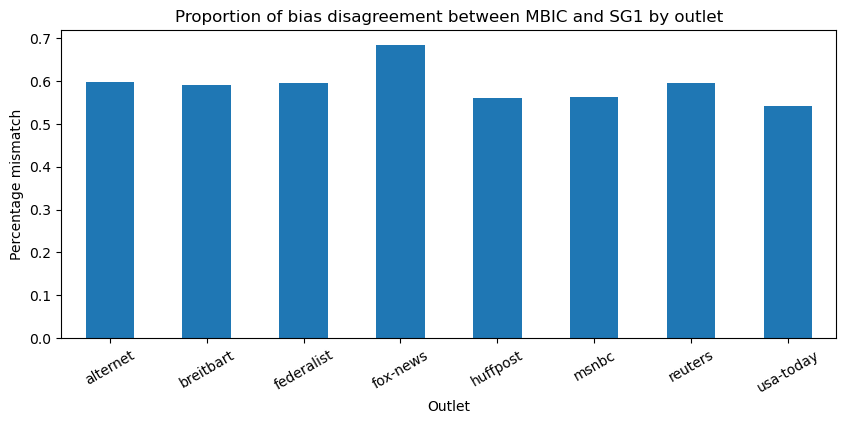

outlet
alternet      0.597633
breitbart     0.591512
federalist    0.596059
fox-news      0.684685
huffpost      0.561404
msnbc         0.561983
reuters       0.594937
usa-today     0.541401
Name: count, dtype: float64

In [77]:
disagreements = label_mismatches['outlet'].value_counts() / (label_mismatches['outlet'].value_counts() + label_matches['outlet'].value_counts())
disagreements.plot(title="Proportion of bias disagreement between MBIC and SG1 by outlet", kind='bar', 
                   xlabel='Outlet', rot=30, ylabel='Percentage mismatch', figsize=[10,4])

plt.show()
disagreements

We can see that Fox News was somewhat more likely to cause disagreement between MBIC and SG1's rating systems, but all of the rest were within six percentage points of each other.

Fox might just be explained by random variance as it's the least represented in the data:

In [78]:
df_sg1['outlet'].value_counts()

outlet
breitbart     377
alternet      338
msnbc         242
federalist    203
reuters       158
usa-today     157
huffpost      114
fox-news      111
Name: count, dtype: int64

## Do the two data sets differ in what kinds of opinions are biased?

Let's look at the `label_opinion` column, which indicates the ideological leaning of the text:

In [87]:
df_sg1['type'].value_counts()

type
left      694
right     691
center    315
Name: count, dtype: int64

In [88]:
df_mbic['type'].value_counts()

type
left      694
right     691
center    315
Name: count, dtype: int64

Remarkably, both data sets contain the same number of left, right, and center labels. It is pretty unlikely that there are major differences in how the two sets of raters perceived the ideological category of the texts. We can  compare the `type` column relative to the `label_bias`es:

In [93]:
mbic_left = df_mbic[df_mbic['type'] == 'left']
mbic_center = df_mbic[df_mbic['type'] == 'center']
mbic_right = df_mbic[df_mbic['type'] == 'right']
sg1_left = df_sg1[df_sg1['type'] == 'left'] 
sg1_center = df_sg1[df_sg1['type'] == 'center']
sg1_right = df_sg1[df_sg1['type'] == 'right']

In [94]:
mbic_left['label_bias'].value_counts()

label_bias
Biased          477
Non-biased      160
No agreement     57
Name: count, dtype: int64

In [95]:
sg1_left['label_bias'].value_counts()

label_bias
Biased          331
Non-biased      296
No agreement     67
Name: count, dtype: int64

For a given left-categorized sentence, MBIC was more likely to call it biased than SG1. Let's check the other two types:

In [96]:
mbic_center['label_bias'].value_counts()

label_bias
Non-biased      200
Biased           88
No agreement     27
Name: count, dtype: int64

In [97]:
sg1_center['label_bias'].value_counts()

label_bias
Non-biased      261
Biased           38
No agreement     16
Name: count, dtype: int64

While both groups were likely to call a center-categorized sentence non-biased, MBIC was also more willing to call these sources biased than SG1.

In [98]:
mbic_right['label_bias'].value_counts()

label_bias
Biased          453
Non-biased      173
No agreement     65
Name: count, dtype: int64

In [99]:
sg1_right['label_bias'].value_counts()

label_bias
Biased          377
Non-biased      243
No agreement     71
Name: count, dtype: int64

MBIC once again discovered more bias than SG1 did coming from right-categorized sentences. MBIC found slightly more bias from the left than the right, while SG1 found more bias coming from the right than the left. We can make a few charts about this:

In [101]:
left_biases = pd.concat([mbic_left['label_bias'].value_counts(), sg1_left['label_bias'].value_counts()], axis=1) 
left_biases.columns=['MBIC (left)', 'SG1 (left)']
left_biases

,MBIC (left),SG1 (left)
label_bias,,
Biased,477,331
Non-biased,160,296
No agreement,57,67


In [102]:
center_biases = pd.concat([mbic_center['label_bias'].value_counts(), sg1_center['label_bias'].value_counts()], axis=1) 
center_biases.columns=['MBIC (center)', 'SG1 (center)']
center_biases

,MBIC (center),SG1 (center)
label_bias,,
Non-biased,200,261
Biased,88,38
No agreement,27,16


In [103]:
right_biases = pd.concat([mbic_right['label_bias'].value_counts(), sg1_right['label_bias'].value_counts()], axis=1) 
right_biases.columns=['MBIC (right)', 'SG1 (right)']
right_biases

,MBIC (right),SG1 (right)
label_bias,,
Biased,453,377
Non-biased,173,243
No agreement,65,71


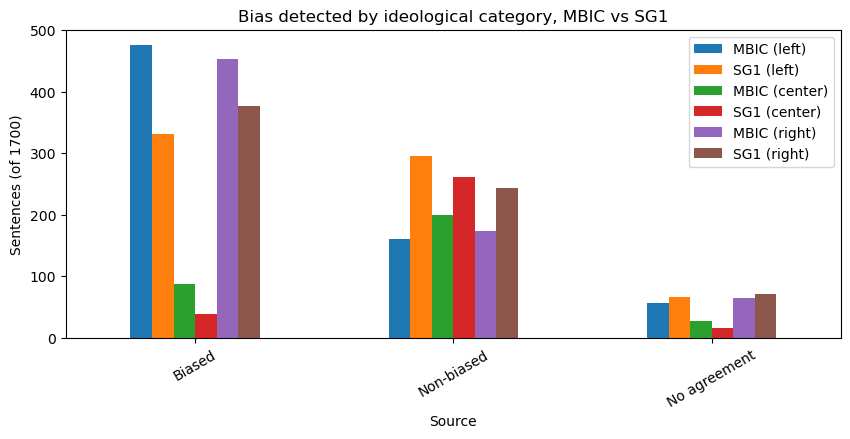

In [ ]:
six_biases = pd.concat([left_biases, center_biases, right_biases], axis=1)

six_biases.plot(title='Bias detected by ideological category, MBIC vs SG1', figsize=[10,4], kind='bar',
                xlabel='Source', rot=30, ylabel='Sentences (of 1700)')

plt.show()

The two leftmost columns in each cluster represent the left-categorized sentences, then the center, then the right. We can see that the MBIC columns are higher than their SG1 counterparts in the "Biased" results, showing that MBIC was more likely to call an article biased across all three categories. Of course, the reverse is true for "Non-biased" results.

We can also see a difference in ideological leaning between the two sets: MBIC identified more left-biased sentences than right-biased ones, while SG1 identified more right-biased sentences than left-biased ones. However, both data sets were relatively unlikely to call center-categorized sentences biased. 

# Training two models

We'll use two logistic regressions, one trained on MBIC's data and one on SG1's data, with their respective `label_bias` columns as targets. We'll then test the models against some scraped Wikipedia pages to see how similar or different the results are. Given the above, **my hypothesis is that MBIC will find more bias in Wikipedia than SG1 will**, but we'll see!

In order to get the models ready for training, we have to do some natural language processing steps:

In [ ]:
#removing the extra column we added earlier
df_mbic = df_mbic.drop('sg1_label_bias', axis=1)
df_mbic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           1700 non-null   object
 1   news_link      1700 non-null   object
 2   outlet         1700 non-null   object
 3   topic          1700 non-null   object
 4   type           1700 non-null   object
 5   label_bias     1700 non-null   object
 6   label_opinion  1700 non-null   object
 7   biased_words   1700 non-null   object
dtypes: object(8)
memory usage: 106.4+ KB


In [ ]:
#TODO tokenize and lemmatize text columns; remove unnecessary extra columns; train models; scrape Wikipedia; test and discuss